# loading the data for each month & combining them together

In [143]:
import sys, os, glob
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), ".")))
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [144]:
# importing nessaary util functions
from utils.utils import load_raw_data

In [145]:
# raw_data_folder should go in the config.yaml
raw_folder_path = "../data/raw"
df = load_raw_data(raw_folder_path = raw_folder_path)

In [146]:
display(df.head())

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,CustomerID,is_churned,Month
0,880.922970,NaN,1,2,0,0,1,16,18,Male,57732,2,CUST0001,0,1
1,NaN,176.144725,1,1,0,2,1,12,51,Male,84085,3,CUST0002,0,1
2,311.763191,145.690171,1,2,0,0,0,15,21,Female,51898,5,CUST0003,0,1
3,414.412773,105.305217,1,4,1,3,1,13,23,Male,72227,3,CUST0004,0,1
4,244.697028,52.308319,1,5,2,3,0,17,41,Female,37707,1,CUST0005,0,1


We notice that customer ID belongs to different people in different month, it might be because of reusable customer ids in the system, which restricts us to recognise same customer over 12 month period. Therefore, **we will be dropping customer ID column due to inconsistency**. Potentially we won't be able to analyse time series data because of that, we might be able to analyse, in which month we had most churned customer, which might give us an idea of potential seasonality impact on the churning of the customers. 

In [134]:
df[df['CustomerID'] == "CUST0001"]

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,CustomerID,is_churned,Month
0,880.922970,NaN,1,2,0,0,1,16,18,Male,57732,2,CUST0001,0,1
1000,253.861015,58.104481,1,5,0,2,0,9,53,Male,73306,4,CUST0001,0,2
2000,401.877251,189.951307,1,0,2,1,1,4,46,Female,43027,3,CUST0001,0,3
3000,94.247066,NaN,1,2,1,2,0,7,33,Male,79574,2,CUST0001,0,4
4000,296.376814,NaN,1,4,0,3,0,17,23,Female,105634,1,CUST0001,0,5
5000,634.875054,171.612221,0,4,2,0,1,18,25,Male,56984,3,CUST0001,0,6
6000,NaN,158.681601,1,0,1,2,1,9,65,Male,115161,1,CUST0001,0,7
7000,732.356843,196.697444,1,5,0,0,0,9,36,Female,54640,1,CUST0001,0,8
8000,374.275191,192.390837,1,3,1,0,0,19,23,Female,44839,3,CUST0001,0,9
9000,655.726875,82.263359,1,4,0,1,0,23,31,Female,34694,4,CUST0001,0,10


In [135]:
#drop customer ID
df.drop("CustomerID", axis=1, inplace=True)

In [136]:
display(df.head())

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
0,880.922970,NaN,1,2,0,0,1,16,18,Male,57732,2,0,1
1,NaN,176.144725,1,1,0,2,1,12,51,Male,84085,3,0,1
2,311.763191,145.690171,1,2,0,0,0,15,21,Female,51898,5,0,1
3,414.412773,105.305217,1,4,1,3,1,13,23,Male,72227,3,0,1
4,244.697028,52.308319,1,5,2,3,0,17,41,Female,37707,1,0,1


### Sense check
We will exolore all the variable so we can find any inconsistency in the data like white spaces, spell checks & then save the cleaned data into processed folder.


<Axes: xlabel='Gender'>

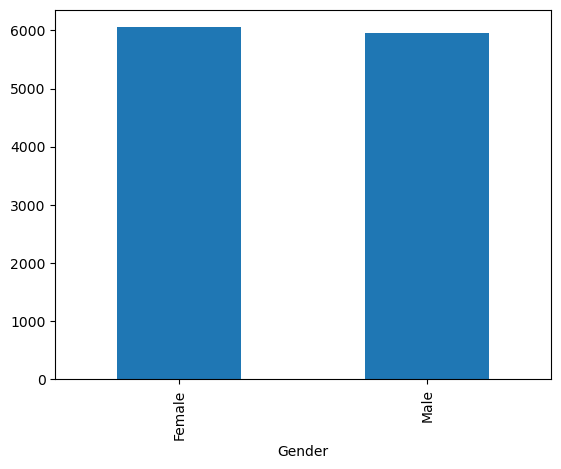

In [137]:
df['Gender'].value_counts().plot(kind='bar')

*Gender* column is well-balanced.

In [138]:
df['PaymentHistory'].value_counts()

PaymentHistory
1    9570
0    2430
Name: count, dtype: int64

Text(0.5, 1.0, 'Is_churned class imbalance')

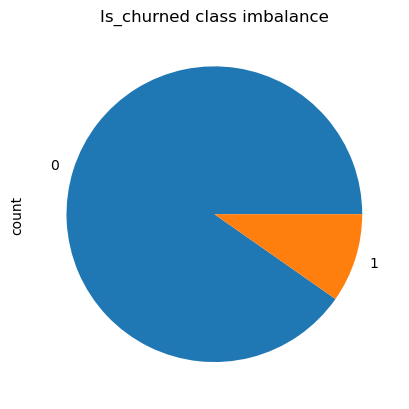

In [139]:
df['is_churned'].value_counts().plot(kind='pie')
plt.title('Is_churned class imbalance')

*PaymentHistory* & *is_chruned* column have class imbalance & we would need to resample the training set when building model

In [140]:
df['CustomerServiceInteractions'].value_counts()

CustomerServiceInteractions
 2    2067
 3    2032
 4    2017
 1    1977
 0    1953
 5    1861
-1      49
 6      44
Name: count, dtype: int64

*CustomerServiceInteractions* is defined as number of interactions with customer service & it cannot be negative so I would be converting them to 0, business opinion is required on what does -1 interaction stands for?

In [141]:
#replacing -1 with zero for CustomerServiceInteractions
df['CustomerServiceInteractions'] = df['CustomerServiceInteractions'].replace(-1, 0)
df['CustomerServiceInteractions'].value_counts()

CustomerServiceInteractions
2    2067
3    2032
4    2017
0    2002
1    1977
5    1861
6      44
Name: count, dtype: int64

In [142]:
df[df['CustomerServiceInteractions'] == 6]

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
198,692.268452,91.103183,0,6,0,2,1,21,44,Female,75050,4,0,1
1363,161.141684,191.491119,1,6,0,0,1,19,44,Female,62948,1,0,2
1525,548.754903,163.948719,1,6,1,3,0,5,57,Male,83969,4,0,2
1538,NaN,NaN,1,6,2,3,1,8,40,Female,92989,5,0,2
1737,670.591941,NaN,1,6,0,1,1,7,36,Female,55483,1,0,2
1814,189.753557,54.938486,1,6,0,3,0,17,40,Female,81853,3,0,2
1886,571.157872,88.833521,1,6,2,2,0,5,61,Male,83806,3,0,2
1893,988.974535,149.054352,1,6,0,3,1,1,33,Female,33201,3,0,2
2101,203.942593,97.209628,0,6,1,3,0,16,39,Female,50763,5,0,3
2518,574.156330,14.088009,1,6,1,3,1,19,22,Male,80524,1,0,3


In [119]:
df['Complaints'].value_counts()

Complaints
2    4066
1    4008
0    3926
Name: count, dtype: int64

In [120]:
df['PromotionsReceived'].value_counts()

PromotionsReceived
0    3130
3    2992
1    2940
2    2938
Name: count, dtype: int64

In [121]:
df['ContractType'].value_counts()

ContractType
1    6002
0    5998
Name: count, dtype: int64

In [122]:
df['ContractDuration'].value_counts()

ContractDuration
10    532
11    527
5     524
1     517
2     515
15    513
22    512
20    512
3     508
24    503
13    500
19    498
23    497
21    497
9     495
17    494
14    493
18    492
8     487
4     484
16    483
6     482
12    476
7     459
Name: count, dtype: int64

*contractDuration* can be binned to short, medium & long term contract. **Generally, contractDuration holds high importance when determining churn prediction in any industry**.

binning could help if the relationship between contractDuration and churn is non-linear, specially if we are training a logistic regression model. 

In [123]:
# age column analysis
df['Age'].describe()

count    12000.000000
mean        43.469583
std         14.920119
min         18.000000
25%         31.000000
50%         43.000000
75%         56.000000
max         69.000000
Name: Age, dtype: float64

*Age* should be binned as well.

In [124]:
# one Hot encoding for the gender variable so our model might perform better.
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df['Gender'].value_counts()

Gender
1    6049
0    5951
Name: count, dtype: int64

In [125]:
df['Income'].describe()

count     12000.000000
mean      72982.569583
std       23475.143951
min       25451.000000
25%       53102.750000
50%       73193.500000
75%       92707.000000
max      120606.000000
Name: Income, dtype: float64

In [126]:
df['HouseholdSize'].value_counts()

HouseholdSize
5    2389
3    2384
4    2357
2    2311
1    2285
6     122
7      69
8      50
9      33
Name: count, dtype: int64

In [127]:
# List of variables to convert to categorical
categorical_vars = ['PaymentHistory', 'ContractType', 'Gender', 'is_churned', 'Month']
df[categorical_vars] = df[categorical_vars].astype('category')
print(df.dtypes)

UsageData                       float64
BillingAmount                   float64
PaymentHistory                 category
CustomerServiceInteractions       int64
Complaints                        int64
PromotionsReceived                int64
ContractType                   category
ContractDuration                  int64
Age                               int64
Gender                         category
Income                            int64
HouseholdSize                     int64
is_churned                     category
Month                          category
dtype: object


In [128]:
# Save the data into processed folder
df.to_csv('../data/processed/churn_data_processed.csv', index=False)